In [ ]:
!pip install biopython pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:00


In [ ]:
import os

def rename_pdbs(directory, prefix="HDOCK"):
    files = [f for f in sorted(os.listdir(directory)) if f.endswith('.pdb')]
    for i, filename in enumerate(files, 1):
        new_name = f"{prefix}_{i:02d}.pdb"
        os.rename(os.path.join(directory, filename), os.path.join(directory, new_name))
    print(f"Renomeados {len(files)} arquivos com o prefixo {prefix}.")

# Uso:
PDB_DIR = '/content/pdb' # Ajuste seu caminho
rename_pdbs(PDB_DIR, "HDOCK")

Renomeados 10 arquivos com o prefixo HDOCK.


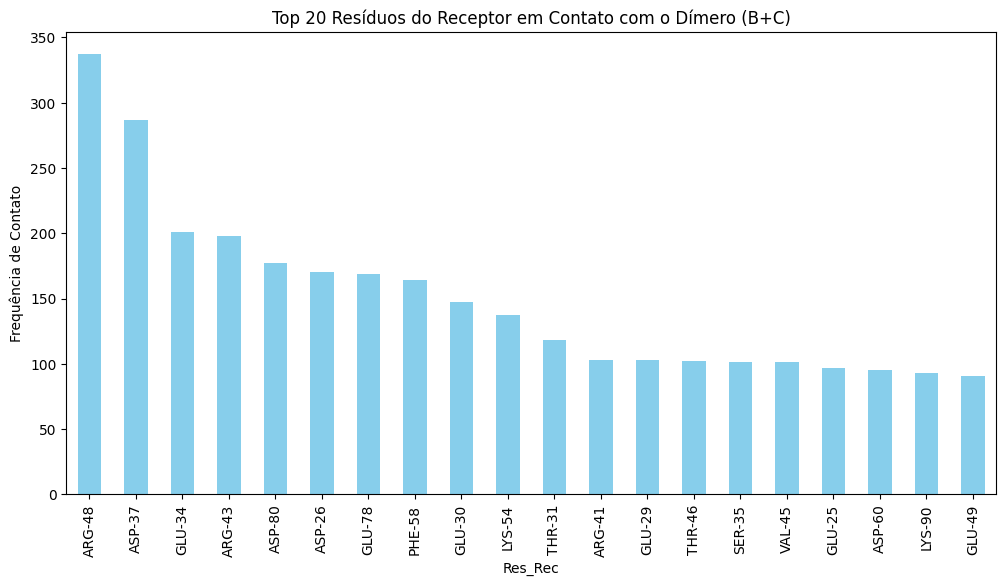

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser, NeighborSearch

PDB_DIR = '/content/pdb'
CUTOFF = 4.0

def get_dimer_interactions(pdb_dir, cutoff=4.0):
    parser = PDBParser(QUIET=True)
    interact_list = []

    files = [f for f in os.listdir(pdb_dir) if f.endswith('.pdb')]

    for f in files:
        structure = parser.get_structure('P', os.path.join(pdb_dir, f))
        model = structure[0]

        # Cadeias: A (Receptor), B e C (Dímero)
        rec = model['A']
        lig_b = model['B']
        lig_c = model['C']

        # Busca vizinhos do Receptor contra as duas cadeias do dímero
        atoms_rec = list(rec.get_atoms())
        ns_rec = NeighborSearch(atoms_rec)

        # Interações com Cadeia B e Cadeia C
        for lig_chain in [lig_b, lig_c]:
            for atom_lig in lig_chain.get_atoms():
                nearby = ns_rec.search(atom_lig.get_coord(), cutoff)
                for atom_rec in nearby:
                    interact_list.append({
                        'PDB': f,
                        'Source': 'HDOCK' if 'HDOCK' in f else 'ClusPro',
                        'Res_Rec': f"{atom_rec.get_parent().get_resname()}-{atom_rec.get_parent().id[1]}",
                        'Res_Lig': f"{atom_lig.get_parent().get_resname()}-{atom_lig.get_parent().id[1]}",
                        'Chain_Lig': lig_chain.id
                    })
    return pd.DataFrame(interact_list)

df_all = get_dimer_interactions(PDB_DIR, CUTOFF)

# Gráfico de Consenso Total
plt.figure(figsize=(12,6))
df_all['Res_Rec'].value_counts().head(20).plot(kind='bar', color='skyblue')
plt.title('Top 20 Resíduos do Receptor em Contato com o Dímero (B+C)')
plt.ylabel('Frequência de Contato')
plt.show()

In [ ]:
def print_output_dimer(df, label, chain_id, is_receptor=True):
    THRESHOLD_ATIVO = 0.5
    THRESHOLD_PASSIVO = 0.2

    # Filtrar dados para a cadeia específica
    if is_receptor:
        target_col = 'Res_Rec'
        sub_df = df.drop_duplicates(['PDB', 'Res_Rec'])
    else:
        target_col = 'Res_Lig'
        sub_df = df[df['Chain_Lig'] == chain_id].drop_duplicates(['PDB', 'Res_Lig'])

    # Frequências
    hdock_freq = sub_df[sub_df['Source'] == 'HDOCK'][target_col].value_counts()
    total_freq = sub_df[target_col].value_counts()

    comp = pd.DataFrame({'HDOCK': hdock_freq, 'Total': total_freq}).fillna(0).astype(int)
    comp['Delta'] = comp['Total'] - comp['HDOCK']
    comp['Ratio'] = comp.apply(lambda x: min(x['HDOCK'], x['Delta']) / max(x['HDOCK'], x['Delta']) if max(x['HDOCK'], x['Delta']) > 0 else 0, axis=1)

    print(f"\n{'='*20} {label} (Cadeia {chain_id}) {'='*20}")
    print("Residuo\tHDOCK\tTotal\tDelta\tRatio\tSugestao")

    ativos, passivos = [], []
    for res, row in comp.sort_values('Total', ascending=False).head(15).iterrows():
        sug = "ATIVO" if row['Ratio'] >= THRESHOLD_ATIVO else "PASSIVO" if row['Ratio'] >= THRESHOLD_PASSIVO else "ESPECIFICO"
        if sug == "ATIVO": ativos.append(res.split('-')[-1])
        elif sug == "PASSIVO": passivos.append(res.split('-')[-1])
        print(f"{res}\t{row['HDOCK']}\t{row['Total']}\t{row['Delta']}\t{row['Ratio']:.2f}\t{sug}")

    print(f"\nLISTA HADDOCK {chain_id}:")
    print(f"Ativos: {','.join(ativos)}")
    print(f"Passivos: {','.join(passivos)}")

# Execução para as 3 cadeias
print_output_dimer(df_all, "RECEPTOR", "A", is_receptor=True)
print_output_dimer(df_all, "LIGANTE PARTE 1", "B", is_receptor=False)
print_output_dimer(df_all, "LIGANTE PARTE 2", "C", is_receptor=False)


==================== RECEPTOR (Cadeia A) ====================
Residuo	HDOCK	Total	Delta	Ratio	Sugestao
ARG-43	9.0	15.0	6.0	0.67	ATIVO
ARG-48	9.0	13.0	4.0	0.44	PASSIVO
THR-46	8.0	12.0	4.0	0.50	ATIVO
PHE-58	9.0	12.0	3.0	0.33	PASSIVO
ALA-89	8.0	11.0	3.0	0.38	PASSIVO
THR-17	8.0	11.0	3.0	0.38	PASSIVO
PRO-91	8.0	11.0	3.0	0.38	PASSIVO
VAL-45	8.0	11.0	3.0	0.38	PASSIVO
ASP-60	9.0	10.0	1.0	0.11	ESPECIFICO
LYS-90	6.0	9.0	3.0	0.50	ATIVO
GLU-49	4.0	8.0	4.0	1.00	ATIVO
GLU-94	6.0	8.0	2.0	0.33	PASSIVO
LYS-54	5.0	8.0	3.0	0.60	ATIVO
GLY-93	6.0	8.0	2.0	0.33	PASSIVO
ILE-44	6.0	8.0	2.0	0.33	PASSIVO

LISTA HADDOCK A:
Ativos: 43,46,90,49,54
Passivos: 48,58,89,17,91,45,94,93,44

==================== LIGANTE PARTE 1 (Cadeia B) ====================
Residuo	HDOCK	Total	Delta	Ratio	Sugestao
ASN-16	4.0	10.0	6.0	0.67	ATIVO
VAL-3	4.0	10.0	6.0	0.67	ATIVO
VAL-18	4.0	10.0	6.0	0.67	ATIVO
LEU-10	3.0	9.0	6.0	0.50	ATIVO
ARG-63	5.0	8.0	3.0	0.60	ATIVO
THR-19	3.0	8.0	5.0	0.60	ATIVO
LYS-7	2.0	7.0	5.0	0.40	PASSIVO
GLY-6	1.0	6.

In [ ]:
import os
import glob

# Defina o caminho
pasta = '/content/pdb'

# Busca todos os arquivos que terminam em .pdb naquela pasta
arquivos = glob.glob(os.path.join(pasta, "*.pdb"))

for f in arquivos:
    try:
        os.remove(f)
    except OSError as e:
        print(f"Erro ao deletar {f}: {e.strerror}")

print(f"Limpeza concluída! {len(arquivos)} arquivos removidos.")

Limpeza concluída! 20 arquivos removidos.
